In [7]:
import sys
print(sys.executable)
print(sys.version)

/opt/homebrew/Cellar/jupyterlab/4.4.6/libexec/bin/python
3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)]


In [8]:
import sys
!{sys.executable} -m pip install lifelines

  Preparing metadata (setup.py) ... done
  Using cached narwhals-2.17.0-py3-none-any.whl.metadata (14 kB)
Using cached narwhals-2.17.0-py3-none-any.whl (444 kB)
  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4119 sha256=3df731f362ede527aa90d37042893db3fef3572a2888b4cf953ee08fc6cc71d1
  Stored in directory: /Users/khushdomadiya/Library/Caches/pip/wheels/7e/16/46/9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
sns.set_theme(style="whitegrid")

In [17]:
validation_path = "/Users/khushdomadiya/Documents/Healthcare/archive/Clinical_Data_Validation_Cohort.xlsx"
df_validation = pd.read_excel(validation_path)  # default reads first sheet

df_validation.head()

,Patient ID,Survival time (days),"Event (death: 1, alive: 0)",Tumor size (cm),Grade,Stage (TNM 8th edition),Age,Sex,Cigarette,Pack per year,Type.Adjuvant,batch,EGFR,KRAS
0,P109342,2329,1,2.6,3,IB,67,Male,Former,50.0,NaN,1,NaN,NaN
1,P124450,2532,0,3.5,3,IB,68,Female,Former,52.5,NaN,1,Negative,Negative
2,P131833,2271,0,2.0,2,IA2,80,Female,Never,0.0,NaN,1,Negative,Negative
3,P131888,2193,0,3.0,2,IA3,63,Male,Former,47.0,NaN,1,Negative,G12C
4,P131946,2387,0,4.0,2,IIIA,88,Female,Never,0.0,NaN,1,Negative,Negative


In [18]:
df = df_validation.copy()

# Standardize treatment
df['Type.Adjuvant'] = (
    df['Type.Adjuvant']
    .fillna('None')
    .replace(['NA', 'na', 'N/A'], 'None')
    .astype(str)
    .str.strip()
)

# Standardize stage + mutation fields (helps avoid hidden whitespace issues)
for col in ['Stage (TNM 8th edition)', 'EGFR', 'KRAS', 'Cigarette', 'Sex']:
    df[col] = df[col].astype(str).str.strip()

# Ensure numeric survival/event
df['Survival time (days)'] = pd.to_numeric(df['Survival time (days)'], errors='coerce')
df['Event (death: 1, alive: 0)'] = pd.to_numeric(df['Event (death: 1, alive: 0)'], errors='coerce')

df = df.dropna(subset=['Survival time (days)', 'Event (death: 1, alive: 0)'])
df[['Survival time (days)', 'Event (death: 1, alive: 0)']].head()


,Survival time (days),"Event (death: 1, alive: 0)"
0,2329,1
1,2532,0
2,2271,0
3,2193,0
4,2387,0


In [19]:
# Kaplan–Meier survival curves

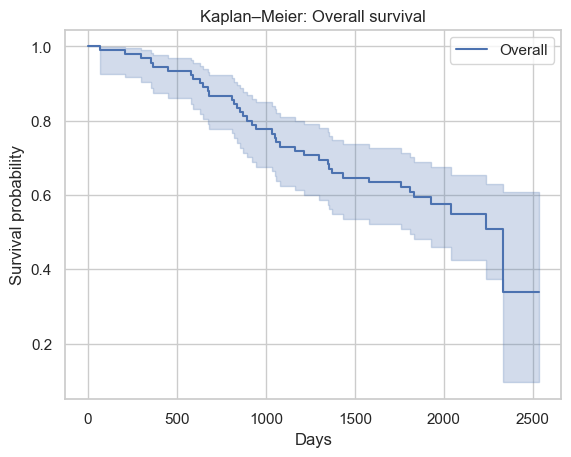

In [20]:
kmf = KaplanMeierFitter()

T = df['Survival time (days)']
E = df['Event (death: 1, alive: 0)']

kmf.fit(T, event_observed=E, label="Overall")
ax = kmf.plot(ci_show=True)
ax.set_title("Kaplan–Meier: Overall survival")
ax.set_xlabel("Days")
ax.set_ylabel("Survival probability")
plt.show()


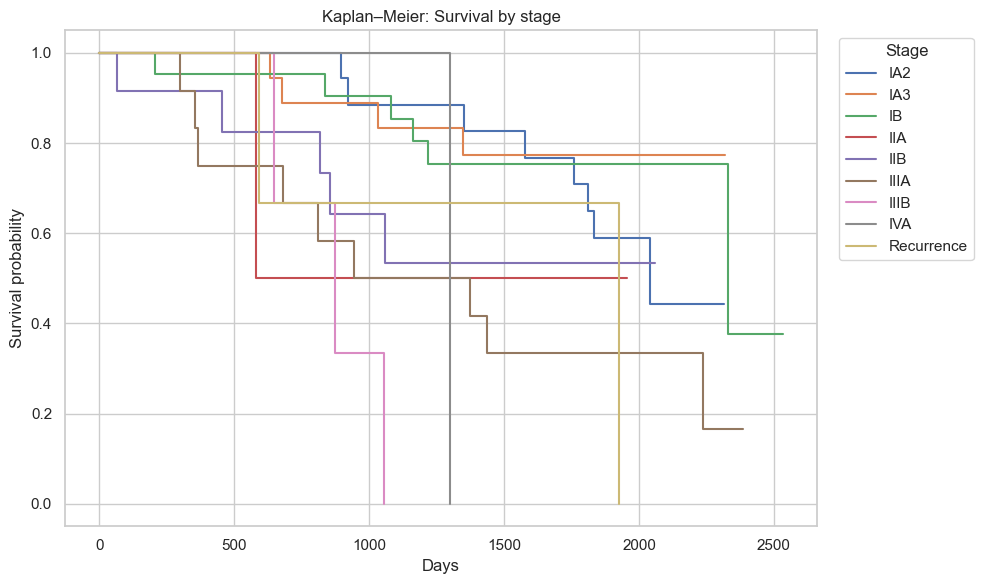

In [21]:
plt.figure(figsize=(10,6))
for stage, g in df.groupby('Stage (TNM 8th edition)'):
    kmf.fit(g['Survival time (days)'], g['Event (death: 1, alive: 0)'], label=stage)
    kmf.plot(ci_show=False)

plt.title("Kaplan–Meier: Survival by stage")
plt.xlabel("Days")
plt.ylabel("Survival probability")
plt.legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [22]:
# Cox proportional hazards model

In [23]:
model_cols = [
    'Survival time (days)',
    'Event (death: 1, alive: 0)',
    'Age',
    'Tumor size (cm)',
    'Grade',
    'Stage (TNM 8th edition)',
    'Type.Adjuvant',
    'EGFR',
    'KRAS',
    'Cigarette',
    'Sex'
]

df_m = df[model_cols].copy()

# Convert numeric columns safely
for col in ['Age', 'Tumor size (cm)', 'Grade']:
    df_m[col] = pd.to_numeric(df_m[col], errors='coerce')

df_m = df_m.dropna(subset=['Age', 'Tumor size (cm)', 'Grade'])

# One-hot encode categorical variables
df_m = pd.get_dummies(
    df_m,
    columns=['Stage (TNM 8th edition)', 'Type.Adjuvant', 'EGFR', 'KRAS', 'Cigarette', 'Sex'],
    drop_first=True
)

df_m.head()


,Survival time (days),"Event (death: 1, alive: 0)",Age,Tumor size (cm),Grade,Stage (TNM 8th edition)_IA3,Stage (TNM 8th edition)_IB,Stage (TNM 8th edition)_IIA,Stage (TNM 8th edition)_IIB,Stage (TNM 8th edition)_IIIA,...,KRAS_G12V,KRAS_G13C,KRAS_G13D,KRAS_G13F,KRAS_G13R,KRAS_Negative,KRAS_nan,Cigarette_Former,Cigarette_Never,Sex_Male
0,2329,1,67,2.6,3,False,True,False,False,False,...,False,False,False,False,False,False,True,True,False,True
1,2532,0,68,3.5,3,False,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
2,2271,0,80,2.0,2,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,2193,0,63,3.0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
4,2387,0,88,4.0,2,False,False,False,False,True,...,False,False,False,False,False,True,False,False,True,False


In [25]:
## Penalized Cox Proportional Hazards Model

In [33]:
from lifelines import CoxPHFitter

# Penalized Cox model to handle collinearity and separation
cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    df_m,
    duration_col='Survival time (days)',
    event_col='Event (death: 1, alive: 0)'
)

cph.print_summary()


<lifelines.CoxPHFitter: fitted with 95 total observations, 56 right-censored observations>
             duration col = 'Survival time (days)'
                event col = 'Event (death: 1, alive: 0)'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 95
number of events observed = 39
   partial log-likelihood = -139.47
         time fit was run = 2026-03-08 01:49:54 UTC

---
                                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                           
Age                                 0.00      1.00      0.02           -0.04            0.04                0.97                1.04
Tumor size (cm)                     0.11      1.12      0.13           -0.14            0.37                0.87                1.44
Grade                               0.45      1.57      0.30           -0.14            1.05                0.87                2.86
Stage (TNM 8th edition)_IA3        -0.59      0.56      0.47           -1.50            0.32                0.22                1.38
Stage (TNM 8th edition)_IB         -0.61      0.55      0.46           -1.50            0.29                0.22                1.34
Stage (TNM 8th edition)_IIA         0.86      2.35      1.09           -1.28            3.00                0.28               20.01
Stage (TNM 8th edition)_IIB         0.34      1.40      0.59           -0.82            1.49                0.44                4.45
Stage (TNM 8th edition)_IIIA        0.29      1.33      0.53           -0.75            1.32                0.47                3.74
Stage (TNM 8th edition)_IIIB        1.38      3.98      0.88           -0.35            3.11                0.70               22.51
Stage (TNM 8th edition)_IVA         1.65      5.19      1.23           -0.77            4.06                0.46               57.95
Stage (TNM 8th edition)_Recurrence  1.00      2.72      0.79           -0.56            2.56                0.57               12.90
Type.Adjuvant_Chemorad              1.29      3.63      0.83           -0.33            2.91                0.72               18.33
Type.Adjuvant_None                  0.08      1.08      0.44           -0.78            0.94                0.46                2.55
Type.Adjuvant_XRT                   0.99      2.70      2.32           -3.56            5.55                0.03              256.73
EGFR_Exon 19 (15bp delete)         -0.97      0.38      1.28           -3.49            1.54                0.03                4.67
EGFR_Exon 19 (24bp delete)         -0.76      0.47      2.41           -5.48            3.96                0.00               52.67
EGFR_Exon 19 (9bp delete)           1.19      3.30      0.93           -0.62            3.01                0.54               20.29
EGFR_Exon 21                        0.86      2.36      0.88           -0.87            2.59                0.42               13.29
EGFR_Exon 21 (L858R)                1.81      6.13      0.91            0.03            3.59                1.03               36.39
EGFR_Negative                       0.18      1.20      0.55           -0.89            1.26                0.41                3.52
EGFR_nan                            0.97      2.63      0.58           -0.17            2.11                0.84                8.25
KRAS_G12C                           0.77      2.15      0.62           -0.44            1.97                0.64                7.21
KRAS_G12D                           0.66      1.94      0.77           -0.85            2.18                0.43                8.82
KRAS_G12F                          -1.28      0.28      1.52           -4.26            1.70                0.01                5.48
KRAS_G12R                          -0.78      0.46      2.39           -5.47            

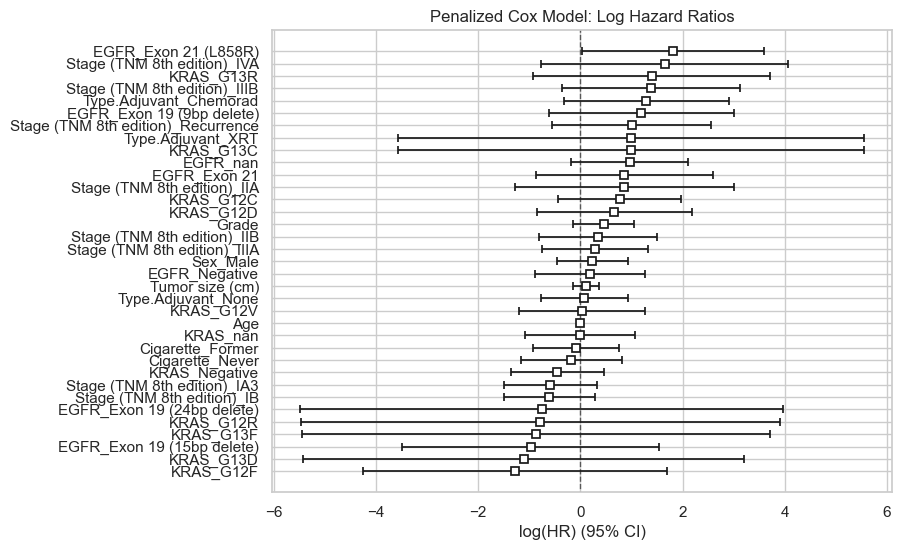

In [27]:
plt.figure(figsize=(8,6))
cph.plot()
plt.title("Penalized Cox Model: Log Hazard Ratios")
plt.show()

In [28]:
cph.check_assumptions(
    df_m,
    p_value_threshold=0.05,
    show_plots=False
)

Proportional hazard assumption looks okay.


[]

In [30]:
# cleaning data for tableau

In [31]:
df_tab = df_validation.copy()

# Clean treatment
df_tab['Type.Adjuvant'] = (
    df_tab['Type.Adjuvant']
    .fillna('None')
    .replace(['NA', 'na', 'N/A'], 'None')
    .astype(str).str.strip()
)

# Strip key categoricals
for col in ['Stage (TNM 8th edition)', 'EGFR', 'KRAS', 'Cigarette', 'Sex']:
    df_tab[col] = df_tab[col].astype(str).str.strip()

# Ensure numeric
df_tab['Survival time (days)'] = pd.to_numeric(df_tab['Survival time (days)'], errors='coerce')
df_tab['Event (death: 1, alive: 0)'] = pd.to_numeric(df_tab['Event (death: 1, alive: 0)'], errors='coerce')

df_tab = df_tab.dropna(subset=['Survival time (days)', 'Event (death: 1, alive: 0)'])

df_tab.to_csv("validation_tableau.csv", index=False)


In [34]:
hr = cph.summary.reset_index().rename(columns={'index':'feature'})
hr['HR'] = np.exp(hr['coef'])
hr['logHR'] = hr['coef']
hr.to_csv("cox_penalized_hr.csv", index=False)